# Raw forecast vs shipped model vs q9 retrain — error & coverage, per tier per metric

One question per figure, and every comparison is computed on the **same rows**, so it is
apples-to-apples throughout.

**The systems compared**

| series | what it is | source |
|---|---|---|
| **raw HRES** | the forecast as-is, no debias | `hres` column of the eval-band feathers (current IFS-pinned feed) |
| **prod (7-level)** | `qn8727_s0`, shipped 2026-07-12 — its baked CQR bands; q25/q75 were probit-interpolated client-side | `eval_bands_{var}.feather` |
| **new (q9)** | `qn8620_s0_q9`, the 9-level retrain under validation — all 9 heads trained, post-CQR | `eval_bands_{var}_qn8620_s0_q9.feather` |
| **new (q9) pre-CQR** | the *same* q9 model's raw quantile heads **before** the per-level conformal shift — appears in the coverage figures only | built + cached in the second code cell |

**The rows.** The eval half of the held-out test months (91 days, 2024-08-01 … 2026-04-30),
inner-joined old∩new on (cell, date) → ~770K rows per variable, minus rows gated in either
build. Truth is identical on every joined row (asserted when the artifacts were built).
Per-tier figures use the subset that has a tier label: the 400-cell latitude-stratified
card replay (~36K rows per variable).

**What "tier" means.** The verdict tier the card would *claim*, replayed with the q9
model's estimate + band against the cell's climatology: `extreme` = rarest 5% of the
±3-day seasonal window, `mid` ≤ 10%, `notable` ≤ 20%, otherwise `mildOff` / `mildDead`
(the middle 60%, two-sided; `mildDead` = 40–60th percentile). One tier labelling (the q9
card's) groups **every** system, so each tier bucket holds the same rows for all series.
`alltime` (n=121) is excluded from the tier panels but counted in ALL.

**Caveats, stated once**
- The HRES feed was rebuilt (IFS-pinned) between the two trains: prod consumed the older
  version-blind feed, which differs on ~⅓ of rows (drift quantified below). "raw HRES"
  here = the current feed.
- Tier labels come from the new card's own claims. Conditioning on a model's own output
  slightly *disfavors* that model inside a tier (selection effect); the ALL column is
  selection-free.
- Precip point error includes dry days; precip **band coverage** uses the wet-forecast
  protocol (forecast ≥ 1 mm), matching the other coverage notebooks.

In [1]:
# --- setup: constants, colors, cached artifacts (no model loads in this cell) ----
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

HERE = Path.cwd()
CACHE_DIR = HERE / "data" / "nb_confidence"
assert CACHE_DIR.exists(), "run from scripts/bias_study/"
NEW_TAG = "qn8620_s0_q9"                     # the 9-level retrain (candidate)
PRECIP_TRACE_MM = 1.0                        # frontend: precip < 1 mm reads as 0 mm

VARS  = ["tmax", "tmin", "wind", "precip"]
UNITS = {"tmax": "°C", "tmin": "°C", "wind": "m/s", "precip": "mm"}
TIER_ORDER   = ["extreme", "mid", "notable", "mildOff", "mildDead"]
BAND_P       = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
BAND_COLS    = ["q01", "lo", "q10", "q25", "mid", "q75", "q90", "hi", "q99"]
LEVEL_LABELS = ["q01", "q05", "q10", "q25", "q50", "q75", "q90", "q95", "q99"]

# one color per system, identical in every figure (Okabe-Ito, CVD-validated).
# raw HRES is deliberately NOT a peer color: white box with ink edge = "no model".
COLOR_RAW    = "#c9c9c9"
COLOR_PRECQR = "#56B4E9"    # q9 heads BEFORE the conformal (CQR) per-level shift
COLOR_PROD   = "#E69F00"    # shipped 7-level model qn8727_s0
COLOR_NEW    = "#0072B2"    # q9 retrain qn8620_s0_q9, post-CQR
INK = "#333333"

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "grid.linestyle": ":", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.axisbelow": True})
pd.set_option("display.width", 170, "display.float_format", lambda v: f"{v:.3f}")

def trace_clamp(values):
    "frontend rule: precip below 1 mm displays as 0 mm (dry day)."
    return np.where(np.asarray(values, float) < PRECIP_TRACE_MM, 0.0, values)

def wilson_halfwidth(rate, n, z=1.96):
    "half-width of the 95% Wilson score interval around a binomial rate."
    denom = 1 + z**2 / n
    return z * np.sqrt(rate * (1 - rate) / n + z**2 / (4 * n**2)) / denom

bands_new  = {v: pd.read_feather(CACHE_DIR / f"eval_bands_{v}_{NEW_TAG}.feather") for v in VARS}
bands_prod = {v: pd.read_feather(CACHE_DIR / f"eval_bands_{v}.feather") for v in VARS}
claims_new = pd.read_feather(CACHE_DIR / f"claims_reliability_{NEW_TAG}.feather")
tier_labels = claims_new.loc[claims_new.tier.notna(), ["key", "date", "var", "tier"]]

print(f"eval rows: new {len(bands_new['tmax']):,} ({bands_new['tmax'].key.nunique()} cells) / "
      f"prod {len(bands_prod['tmax']):,} ({bands_prod['tmax'].key.nunique()} cells), "
      f"dates {bands_new['tmax'].date.min().date()}..{bands_new['tmax'].date.max().date()}")
print(f"tier labels: {len(tier_labels):,} card replays on {tier_labels.key.nunique()} sampled cells")

eval rows: new 784,420 (8620 cells) / prod 794,157 (8727 cells), dates 2024-08-01..2026-04-30
tier labels: 143,416 card replays on 400 sampled cells


In [2]:
# --- the q9 model's bands BEFORE conformal calibration (pre-CQR), cached ---------
#     Same recipe that baked eval_bands_{var}_{TAG} (cdf_rung_coverage cell 5) EXCEPT
#     the per-level CQR shift is zero: sorted raw quantile heads + the same 2-dp
#     rounding, nonneg floor and precip trace clamp. The median head carries no CQR
#     shift in production either, so `mid` must come out IDENTICAL to the post-CQR
#     feather — asserted, which doubles as proof this reproduces the real pipeline.
#     Skip-if-exists: models + the pipeline frame load only when a cache is missing.

def load_eval_frame():
    "pipeline frame restricted to the eval half of the test blocks (odd blocks)."
    import train_quantile_debias as tqd
    needed_cols = (["key", "date", "role", "fc_version"]
                   + [f"bias_{v}" for v in VARS] + [tqd.hres_col(v) for v in VARS]
                   + tqd.GEO_FEATURES + tqd.SEASONAL_FEATURES)
    frame = pd.read_feather("data/pipeline_frame_full.feather", columns=needed_cols)

    # guard: a stale frame with pre-fix fc_version labels would poison the features
    expected = pd.Series(tqd.FC_BASE, index=frame.index)
    for change_date, cycle in sorted(tqd.FC_CHANGES):
        expected = expected.mask(frame["date"] >= change_date, cycle)
    n_stale = int((frame["fc_version"].astype(str) != expected.astype(str)).sum())
    assert n_stale == 0, f"stale fc_version labels on {n_stale:,} rows — rebuild the frame"

    origin = frame.date.min().normalize()
    block = (frame.date.dt.year - origin.year) * 12 + (frame.date.dt.month - origin.month)
    test_blocks = np.sort(block[frame.role == "test"].unique())
    eval_blocks = set(test_blocks[1::2])                 # odd test blocks = eval half
    return frame[(frame.role == "test") & block.isin(eval_blocks)]

eval_frame = None

def build_precqr_bands(var_name):
    global eval_frame
    cache = CACHE_DIR / f"eval_bands_precqr_{var_name}_{NEW_TAG}.feather"
    if cache.exists():
        print(f"[{var_name}] cached {cache.name}")
        return pd.read_feather(cache)

    import train_quantile_debias as tqd
    from catboost import CatBoostRegressor
    if eval_frame is None:
        eval_frame = load_eval_frame()
    var_spec = next(v for v in tqd.VARS if v["name"] == var_name)
    rows = eval_frame[eval_frame[f"bias_{var_name}"].notna()]
    features = (rows[tqd.feature_cols(var_name, with_cell=True, with_cross=False)]
                .astype({"key": str, "fc_version": str}))

    model = CatBoostRegressor()
    model.load_model(str(tqd.MODELS / f"M3_base_{var_name}_{NEW_TAG}.cbm"))
    chunk = 200_000                                       # tmax model is ~400 MB
    heads = np.concatenate(
        [np.sort(np.asarray(model.predict(features.iloc[s:s + chunk])), axis=1)
         for s in range(0, len(features), chunk)], axis=0)
    del model

    hres = rows[tqd.hres_col(var_name)].to_numpy()
    band_abs = hres[:, None] + np.round(heads, 2)         # NO CQR shift — that's the point
    if var_spec["nonneg"]:
        band_abs = np.maximum(band_abs, 0.0)
    band_abs = np.round(band_abs, 3)
    truth_abs = hres + rows[f"bias_{var_name}"].to_numpy()
    if var_name == "precip":
        band_abs = trace_clamp(band_abs)
        truth_abs = trace_clamp(truth_abs)

    out = pd.DataFrame({"key": rows.key.to_numpy(), "date": rows.date.to_numpy(),
                        "hres": hres.astype("float32"),
                        "truth_abs": truth_abs.astype("float32")})
    for j, col in enumerate(BAND_COLS):
        out[col] = band_abs[:, j]

    # must be the exact same rows as the cached post-CQR feather, with identical mid
    post = bands_new[var_name]
    assert (out.key.to_numpy() == post.key.to_numpy()).all() and \
           (out.date.to_numpy() == post.date.to_numpy()).all(), f"{var_name}: row mismatch"
    mid_gap = float(np.abs(out["mid"].to_numpy() - post["mid"].to_numpy()).max())
    assert mid_gap <= 1e-6, f"{var_name}: pre-CQR median differs from pipeline ({mid_gap})"
    out["gated"] = post.gated.to_numpy()
    out.to_feather(cache)
    print(f"[{var_name}] built {len(out):,} rows -> {cache.name} (mid reproduces exactly)")
    return out

bands_precqr = {v: build_precqr_bands(v) for v in VARS}
eval_frame = None                                          # free ~1 GB if it was loaded
{v: len(df) for v, df in bands_precqr.items()}

[tmax] cached eval_bands_precqr_tmax_qn8620_s0_q9.feather
[tmin] cached eval_bands_precqr_tmin_qn8620_s0_q9.feather
[wind] cached eval_bands_precqr_wind_qn8620_s0_q9.feather


[precip] cached eval_bands_precqr_precip_qn8620_s0_q9.feather


{'tmax': 784420, 'tmin': 784420, 'wind': 784420, 'precip': 784420}

In [3]:
# --- one comparison frame per variable: the SAME eval rows for every system ------
#     full_rows[var] : old∩new joined eval rows, non-gated in BOTH builds
#                      (histograms + marginal coverage run on these, ~750K rows)
#     tier_rows[var] : the subset with a tier label from the q9 card replay
#                      (all per-tier figures run on these, ~35K rows)
#     Band column suffixes: none = new (q9), _prod = shipped 7-level, _pre = q9 pre-CQR.

def assemble(var):
    merged = (bands_new[var]
              .merge(bands_prod[var], on=["key", "date"], suffixes=("", "_prod"))
              .merge(bands_precqr[var][["key", "date"] + BAND_COLS],
                     on=["key", "date"], suffixes=("", "_pre")))
    merged = merged[~merged.gated & ~merged.gated_prod].copy()
    # the raw-forecast "prediction" — trace-clamped for precip like everything else
    merged["raw_pred"] = trace_clamp(merged.hres) if var == "precip" else merged.hres
    labels = tier_labels.loc[tier_labels["var"] == var, ["key", "date", "tier"]]
    with_tiers = merged.merge(labels, on=["key", "date"], how="inner",
                              validate="one_to_one")
    return merged, with_tiers

full_rows, tier_rows = {}, {}
for var in VARS:
    full_rows[var], tier_rows[var] = assemble(var)

# how different was the feed prod actually consumed? (HRES was rebuilt IFS-pinned)
feed_drift = pd.DataFrame({var: {
        "common rows": len(full_rows[var]),
        "% rows feeds differ": 100 * (np.abs(full_rows[var].hres
                                             - full_rows[var].hres_prod) > 0.005).mean(),
        "mean |Δfeed|": np.abs(full_rows[var].hres - full_rows[var].hres_prod).mean(),
        "p99 |Δfeed|": np.abs(full_rows[var].hres - full_rows[var].hres_prod).quantile(0.99),
    } for var in VARS}).T
print("common eval rows (non-gated in both builds) + old-vs-new HRES feed drift:")
print(feed_drift.round(3).to_string())

tier_counts = pd.DataFrame({var: tier_rows[var].tier.value_counts() for var in VARS}) \
    .reindex(TIER_ORDER + ["alltime"])
print("\ntier-labelled rows per variable (q9 card replay, 400-cell sample):")
print(tier_counts.to_string())

common eval rows (non-gated in both builds) + old-vs-new HRES feed drift:
        common rows  % rows feeds differ  mean |Δfeed|  p99 |Δfeed|
tmax     766402.000               34.022         0.359        3.200
tmin     771134.000               34.106         0.368        3.300
wind     771589.000               34.508         0.338        3.050
precip   727363.000                9.208         0.512       11.400

tier-labelled rows per variable (q9 card replay, 400-cell sample):
           tmax   tmin   wind  precip
tier                                 
extreme    3949   4967   1637    1005
mid        3767   4326   2481    1335
notable    7241   7765   6437    3189
mildOff   13867  12753  16412   21209
mildDead   6812   5988   9059    6564
alltime      36     55     10       4


## Part 1 — point-prediction error: how far is the number on the card from reality?

Two figures, same three series everywhere (**white box with ink edge = raw forecast**,
orange = prod, blue = q9):

1. **Signed error per tier, as boxplots** — the *bias* the debias models exist to
   remove. Each box is the distribution of that group's days: box = middle 50% of days
   with the median line, whiskers = 5th–95th percentile, **dot = the mean** (with
   `SHOW_OUTLIERS = True`, the small dots beyond the whiskers are individual days). A box
   sitting above the dashed 0 line = predicts too high. Note that
   `extreme`/`mid`/`notable` mix rare-high and rare-low days, so opposite biases can
   partially cancel; the histograms show the full shape.
2. **Overlaid error histograms** — raw filled, models as step outlines, on the full
   ~750K common rows (not just the tier sample). Precip switches to wet-forecast days
   there, where the error distribution is non-degenerate.

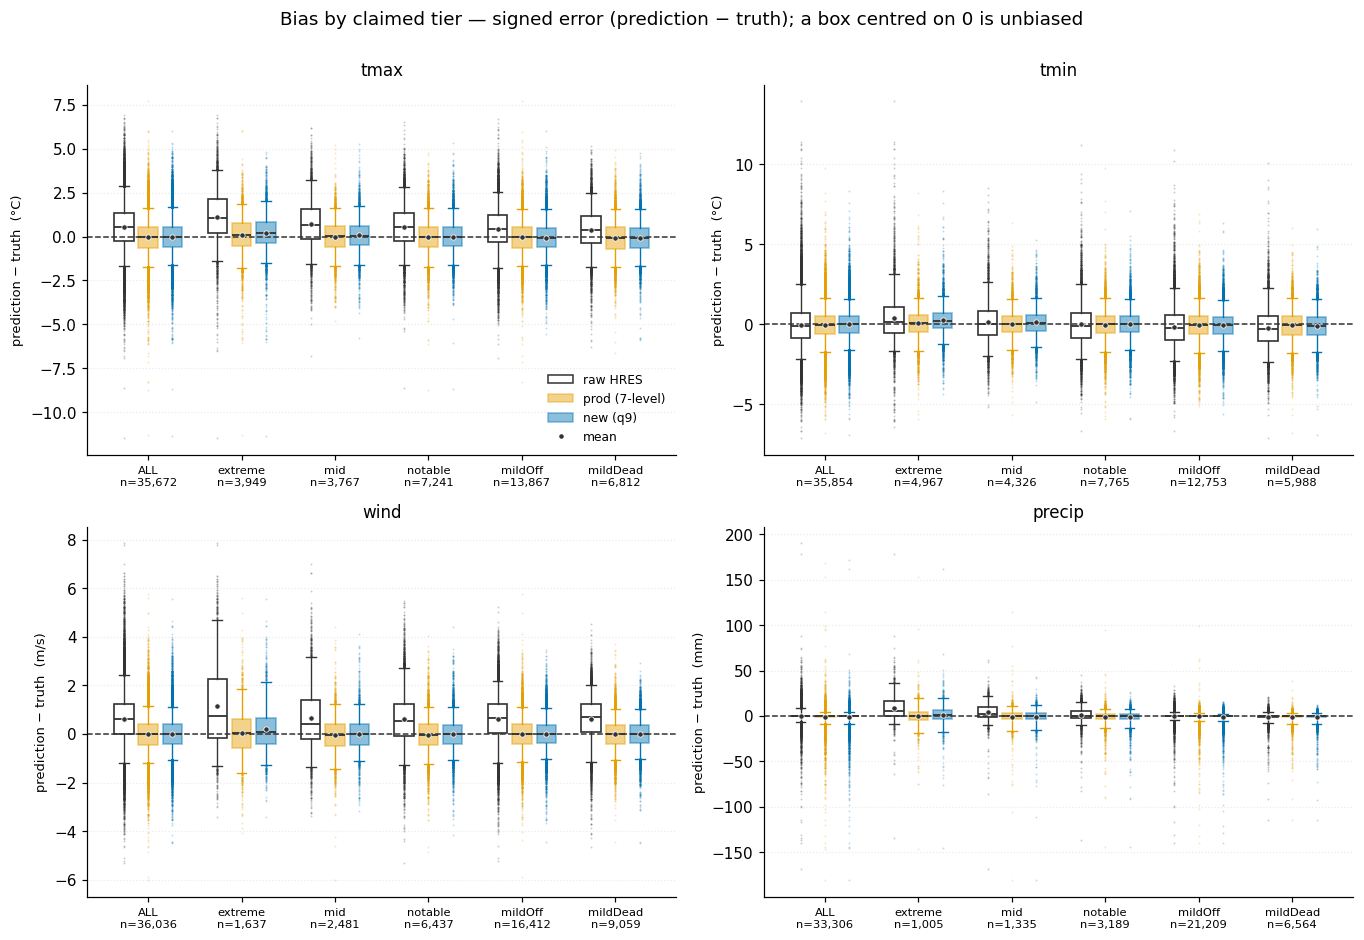

In [4]:
# --- figure 1: SIGNED error per tier (box above the 0 line = predicts too high) --
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

GROUPS = ["ALL"] + TIER_ORDER
SYSTEMS_POINT = [("raw HRES", "raw_pred", COLOR_RAW),
                 ("prod (7-level)", "mid_prod", COLOR_PROD),
                 ("new (q9)", "mid", COLOR_NEW)]

def tier_groups(rows):
    "ALL first (every tier-labelled row, alltime included), then the 5 tiers."
    return [("ALL", rows)] + [(t, rows[rows.tier == t]) for t in TIER_ORDER]

SHOW_OUTLIERS = True     # False hides the dots beyond the 5–95% whiskers (individual days)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5))
x = np.arange(len(GROUPS)); slot_width = 0.26
for ax, var in zip(axes.flat, VARS):
    rows = tier_rows[var]
    for slot, (label, col, color) in enumerate(SYSTEMS_POINT):
        is_raw = color == COLOR_RAW
        samples = [group[col].to_numpy() - group.truth_abs.to_numpy()
                   for _, group in tier_groups(rows)]
        parts = ax.boxplot(samples, positions=x + (slot - 1) * slot_width,
                           widths=slot_width * 0.8, whis=(5, 95),
                           showfliers=SHOW_OUTLIERS,
                           flierprops=dict(marker=".", markersize=2.5,
                                           markerfacecolor=INK if is_raw else color,
                                           alpha=0.25, markeredgecolor="none"),
                           patch_artist=True, manage_ticks=False, showmeans=True,
                           meanprops=dict(marker="o", markersize=3.5,
                                          markerfacecolor=INK,
                                          markeredgecolor="white",
                                          markeredgewidth=0.5),
                           medianprops=dict(color=INK, lw=1.2))
        for box in parts["boxes"]:
            box.set(facecolor="white" if is_raw else color,
                    alpha=1.0 if is_raw else 0.45,
                    edgecolor=INK if is_raw else color, linewidth=1.1)
        for part_name in ("whiskers", "caps"):
            for line in parts[part_name]:
                line.set(color=INK if is_raw else color, lw=0.9)
    ax.axhline(0, color=INK, lw=1, linestyle="--")
    counts = [len(rows)] + [int((rows.tier == t).sum()) for t in TIER_ORDER]
    ax.set_xticks(x)
    ax.set_xticklabels([f"{g}\nn={n:,}" for g, n in zip(GROUPS, counts)], fontsize=7.5)
    ax.set_title(var, fontsize=11)
    ax.set_ylabel(f"prediction − truth  ({UNITS[var]})", fontsize=8.5)
    ax.grid(axis="x", visible=False)
legend_handles = ([Patch(facecolor="white" if color == COLOR_RAW else color,
                         alpha=1.0 if color == COLOR_RAW else 0.45,
                         edgecolor=INK if color == COLOR_RAW else color, label=label)
                   for label, _, color in SYSTEMS_POINT]
                  + [Line2D([], [], marker="o", linestyle="", markersize=4,
                            markerfacecolor=INK, markeredgecolor="white",
                            label="mean")])
axes[0, 0].legend(handles=legend_handles, fontsize=8, frameon=False)
fig.suptitle("Bias by claimed tier — signed error (prediction − truth); "
             "a box centred on 0 is unbiased", y=1.0)
fig.tight_layout()
plt.show()

### The full error distributions

Same three series, full common rows. The raw forecast's histogram is the filled grey
shape; each model is a step outline on identical bins, so a taller peak at zero and
thinner tails literally mean "more days predicted more accurately". Tails are clipped at
raw's 0.5/99.5 percentiles (clipped mass piles into the outermost bins).

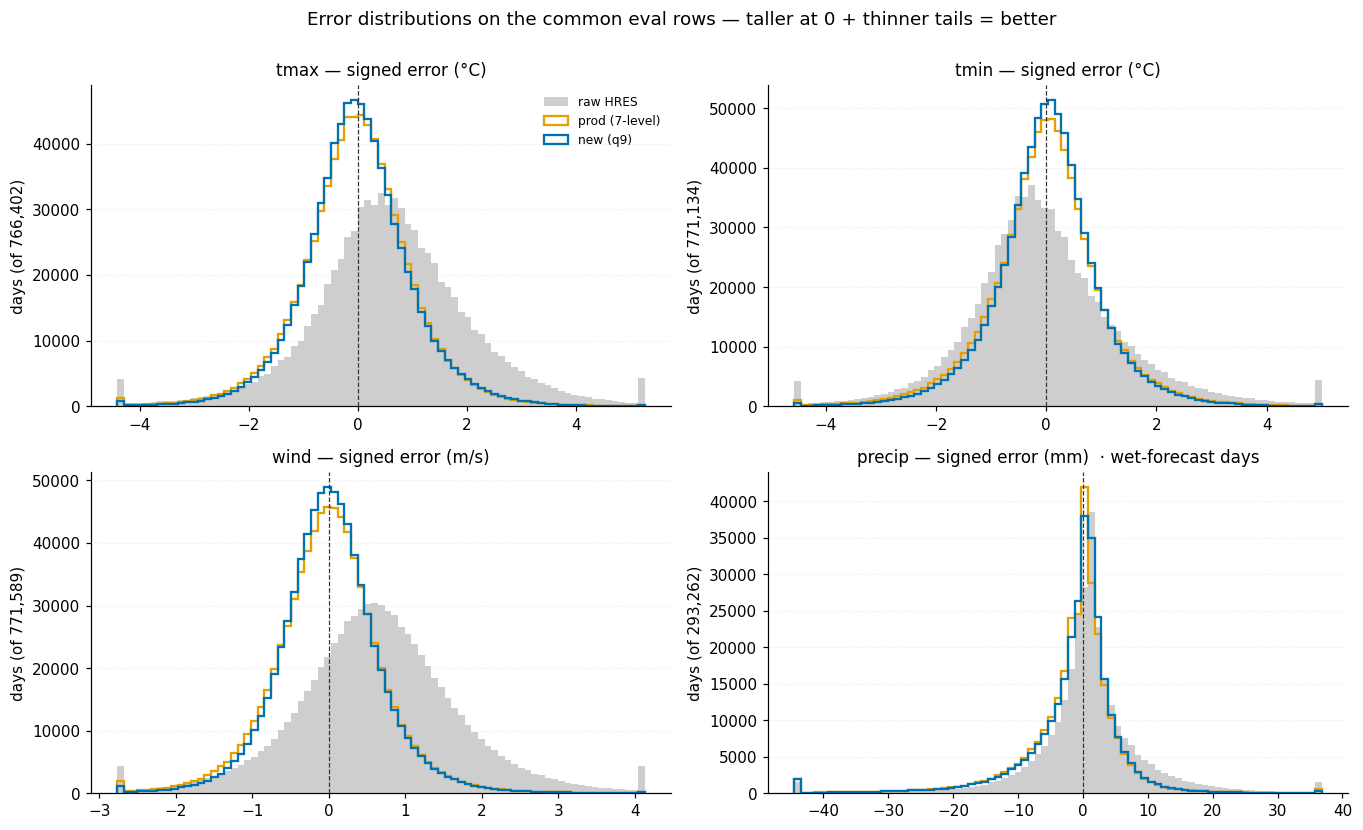

In [5]:
# --- figure 2: overlaid signed-error histograms (raw filled, models as steps) ----
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.5))
for ax, var in zip(axes.flat, VARS):
    rows = full_rows[var]
    if var == "precip":
        rows = rows[rows.hres >= PRECIP_TRACE_MM]          # wet-forecast days only
    errors = {label: rows[col].to_numpy() - rows.truth_abs.to_numpy()
              for label, col, _ in SYSTEMS_POINT}
    lo_edge, hi_edge = np.percentile(errors["raw HRES"], [0.5, 99.5])
    bins = np.linspace(lo_edge, hi_edge, 80)
    ax.hist(np.clip(errors["raw HRES"], lo_edge, hi_edge), bins=bins,
            color=COLOR_RAW, alpha=0.9, label="raw HRES")
    ax.hist(np.clip(errors["prod (7-level)"], lo_edge, hi_edge), bins=bins,
            histtype="step", lw=1.5, color=COLOR_PROD, label="prod (7-level)")
    ax.hist(np.clip(errors["new (q9)"], lo_edge, hi_edge), bins=bins,
            histtype="step", lw=1.5, color=COLOR_NEW, label="new (q9)")
    ax.axvline(0, color=INK, lw=0.8, linestyle="--")
    ax.set_title(f"{var} — signed error ({UNITS[var]})"
                 + ("  · wet-forecast days" if var == "precip" else ""), fontsize=11)
    ax.set_ylabel(f"days (of {len(rows):,})")
    ax.grid(axis="x", visible=False)
axes[0, 0].legend(fontsize=8, frameon=False)
fig.suptitle("Error distributions on the common eval rows — "
             "taller at 0 + thinner tails = better", y=1.0)
fig.tight_layout()
plt.show()

## Part 2 — band coverage: does each band hold as many days as it promises?

Every band the card shows is a **frequency promise**: the q10–q90 band promises to
contain the truth on **80%** of days, q05–q95 on **90%** (left / right column of the
figure). One figure, two cuts at once:

**Across cells.** The y-axis is raw measured coverage, 0–100% of days: each cell in a
group gets its *own* measured coverage over its days, and the box is the spread of
that across the sampled cells (with `SHOW_OUTLIERS = True`, dots beyond the whiskers
are individual cells). The dashed line is the promise — a box sitting on it keeps the
promise. This answers a question a pooled number can't: *is the band calibrated
everywhere, or right on average while broken per place?*

**How to read the grey box.** It is the null distribution: what a colored box would
look like if that band were perfectly calibrated and only finite-sample luck remained
(binomial at that group's median days-per-cell). So: colored box wider than the grey
one = real spatial heterogeneity; colored box shifted *relative to the grey one* =
miscalibration. The grey box usually is *not* centred on the promise line — with n
days a cell's measured coverage moves in 1/n-size jumps and the promise is rarely a
multiple of 1/n, so even a perfect band's median cell sits a little off it, and
binomial(n, 0.8–0.9) is skewed against the 100% ceiling, which makes the quantiles
asymmetric. A perfect band's *mean* IS the promise — that is the grey dot. Cells whose
band held on every single day pile up at the top of the scale (100%).

**Per claimed tier.** The ALL column uses every tier-labelled day (~89 per cell); inside
a tier a cell contributes only its ~2–10 matching days, so cells with fewer than
`MIN_DAYS_PER_CELL` days in a group are dropped from it and the luck boxes widen a lot —
in the sparse tiers read the mean dots (≈ the pooled per-tier coverage, printed under
the figure) against the grey box, not the whiskers.

**The pooled table's unit: percentage points of days**, measured − promised. Example,
at the 80% band: −3 means the band actually contained the truth on 77% of days —
promise broken, band too narrow (over-confident: the bad direction for trust). +2
means it held on 82% of days — promise kept with room to spare, but wider than it
needed to be (that width cost is quantified in the summary cell).

A third series joins here: the q9 heads **before** the conformal (CQR) shift
(sky-blue). The sky → dark-blue gap is exactly what CQR calibration buys.

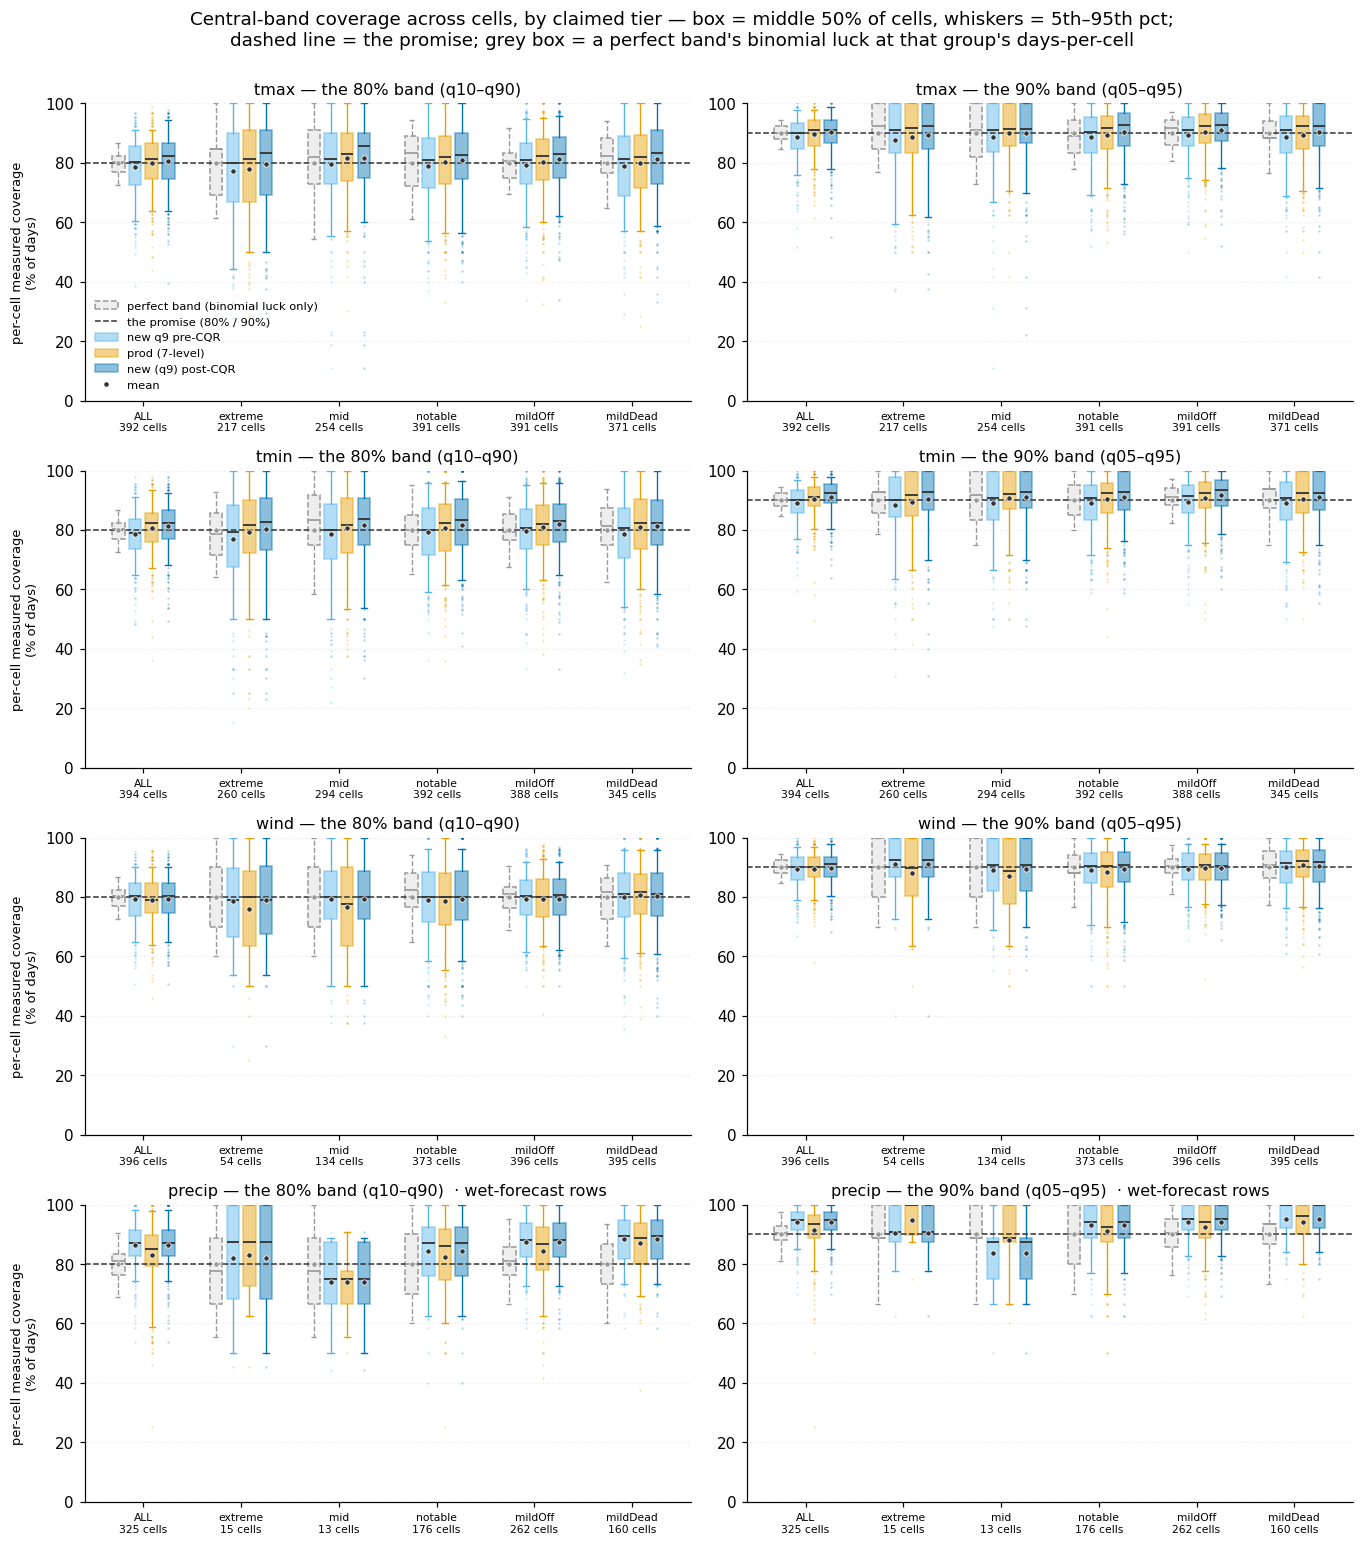

pooled measured − promised coverage (percentage points of days):
                                ALL  extreme    mid  notable  mildOff  mildDead
tmax   80% new q9 pre-CQR    -1.400   -4.900 -0.600   -1.200   -0.700    -1.200
           prod (7-level)    -0.200   -3.700  1.100    0.200    0.400    -0.100
           new (q9) post-CQR  0.700   -2.700  1.500    0.800    1.400     1.000
       90% new q9 pre-CQR    -1.400   -4.100 -1.600   -1.200   -0.600    -1.400
           prod (7-level)    -0.400   -2.700 -0.200   -0.400    0.300    -0.600
           new (q9) post-CQR  0.300   -2.600 -0.100    0.600    1.100     0.300
tmin   80% new q9 pre-CQR    -1.300   -2.600 -1.500   -0.800   -0.700    -2.000
           prod (7-level)     0.600   -0.700  0.900    0.800    0.900     0.900
           new (q9) post-CQR  1.500    0.600  1.500    1.800    1.900     0.700
       90% new q9 pre-CQR    -0.900   -1.400 -1.100   -1.100   -0.500    -1.300
           prod (7-level)     0.500   -0.200  0.600    

In [6]:
# --- figure 3: central-band coverage across cells, split by claimed tier ---------
#     Per cell within a group: the fraction of its days the central band contained
#     truth, on the raw 0–100% scale — the dashed line is the promise (80% / 90%).
#     The grey reference box = a PERFECT band's spread from binomial luck alone at
#     that group's median per-cell day count — only spread beyond it is real spatial
#     heterogeneity, a box shifted relative to it = miscalibration. Tier subsets
#     leave few days per cell (extreme wind = a handful), so the luck boxes widen a
#     lot there; the mean dots still carry the aggregate signal. Precip keeps
#     wet-forecast rows; a cell needs >= MIN_DAYS_PER_CELL days in a group to enter
#     that group's boxes.
from scipy.stats import binom

SYSTEMS_BAND = [("new q9 pre-CQR", "_pre", COLOR_PRECQR),
                ("prod (7-level)", "_prod", COLOR_PROD),
                ("new (q9) post-CQR", "", COLOR_NEW)]
CENTRAL_INTERVALS = [("80% band (q10–q90)", "q10", "q90", 0.80),
                     ("90% band (q05–q95)", "lo", "hi", 0.90)]
BOX_QUANTILES = [0.05, 0.25, 0.50, 0.75, 0.95]   # whisker-lo, box, median, box, whisker-hi
MIN_DAYS_PER_CELL = 8
SHOW_OUTLIERS = True     # False hides the dots beyond the 5–95% whiskers (individual cells)

def central_coverage(rows, suffix, lo_col, hi_col, promised):
    "measured − promised (pp of days) for one central band, + Wilson half-width."
    truth = rows.truth_abs.to_numpy()
    held = ((truth >= rows[lo_col + suffix].to_numpy())
            & (truth <= rows[hi_col + suffix].to_numpy())).mean()
    return 100 * (held - promised), 100 * wilson_halfwidth(held, len(truth))

def per_cell_coverage(rows, suffix, lo_col, hi_col):
    "per-cell measured coverage in % of days, cells with enough days only."
    truth = rows.truth_abs.to_numpy()
    held = ((truth >= rows[lo_col + suffix].to_numpy())
            & (truth <= rows[hi_col + suffix].to_numpy()))
    per_cell = pd.DataFrame({"key": rows.key.to_numpy(), "held": held}) \
        .groupby("key")["held"].agg(["mean", "size"])
    per_cell = per_cell[per_cell["size"] >= MIN_DAYS_PER_CELL]
    median_days = int(per_cell["size"].median()) if len(per_cell) else 0
    return 100 * per_cell["mean"], median_days

def perfect_band_box(n_days, promised):
    "bxp stats for a PERFECTLY calibrated band: binomial(n_days, promised) quantiles."
    lo_whisk, q1, med, q3, hi_whisk = [
        100 * binom.ppf(q, n_days, promised) / n_days for q in BOX_QUANTILES]
    return dict(whislo=lo_whisk, q1=q1, med=med, q3=q3, whishi=hi_whisk,
                mean=100 * promised, fliers=[])    # a perfect band's MEAN is the promise

fig, axes = plt.subplots(len(VARS), 2, figsize=(12.5, 14))
x = np.arange(len(GROUPS)); slot_width = 0.17
for row_i, var in enumerate(VARS):
    rows = tier_rows[var]
    if var == "precip":
        rows = rows[rows.hres >= PRECIP_TRACE_MM]          # wet-forecast rows only
    groups = tier_groups(rows)
    for col_i, (interval_label, lo_col, hi_col, promised) in enumerate(CENTRAL_INTERVALS):
        ax = axes[row_i, col_i]
        cells_per_group = []
        for group_i, (group_name, group) in enumerate(groups):
            coverage_q9, median_days = per_cell_coverage(group, "", lo_col, hi_col)
            cells_per_group.append(len(coverage_q9))
            if median_days == 0:                           # no cell has enough days
                continue
            # grey reference first: a perfect band's binomial-luck spread
            reference = ax.bxp([perfect_band_box(median_days, promised)],
                               positions=[group_i - 1.5 * slot_width],
                               widths=slot_width * 0.75, showfliers=False,
                               patch_artist=True, manage_ticks=False, showmeans=True,
                               meanprops=dict(marker="o", markersize=3.5,
                                              markerfacecolor="#999999",
                                              markeredgecolor="white",
                                              markeredgewidth=0.5))
            reference["boxes"][0].set(facecolor="#eeeeee", edgecolor="#999999",
                                      linewidth=1.0, linestyle="--")
            reference["medians"][0].set(color="#999999", lw=1.1)
            for part_name in ("whiskers", "caps"):
                for line in reference[part_name]:
                    line.set(color="#999999", lw=0.9, linestyle="--")
            for slot, (label, suffix, color) in enumerate(SYSTEMS_BAND):
                coverage, _ = per_cell_coverage(group, suffix, lo_col, hi_col)
                parts = ax.boxplot([coverage.to_numpy()],
                                   positions=[group_i + (slot - 0.5) * slot_width],
                                   widths=slot_width * 0.75, whis=(5, 95),
                                   showfliers=SHOW_OUTLIERS, patch_artist=True,
                                   flierprops=dict(marker=".", markersize=3,
                                                   markerfacecolor=color, alpha=0.3,
                                                   markeredgecolor="none"),
                                   manage_ticks=False, showmeans=True,
                                   meanprops=dict(marker="o", markersize=3.5,
                                                  markerfacecolor=INK,
                                                  markeredgecolor="white",
                                                  markeredgewidth=0.5),
                                   medianprops=dict(color=INK, lw=1.2))
                parts["boxes"][0].set(facecolor=color, alpha=0.45,
                                      edgecolor=color, linewidth=1.1)
                for part_name in ("whiskers", "caps"):
                    for line in parts[part_name]:
                        line.set(color=color, lw=0.9)
        ax.axhline(100 * promised, color=INK, lw=1, linestyle="--")
        ax.set_ylim(0, 100)
        ax.set_xticks(x)
        ax.set_xticklabels([f"{g}\n{n:,} cells"
                            for g, n in zip(GROUPS, cells_per_group)], fontsize=7)
        wet = "  · wet-forecast rows" if var == "precip" else ""
        ax.set_title(f"{var} — the {interval_label}{wet}", fontsize=10.5)
        ax.grid(axis="x", visible=False)
    axes[row_i, 0].set_ylabel("per-cell measured coverage\n(% of days)", fontsize=8.5)
legend_handles = ([Patch(facecolor="#eeeeee", edgecolor="#999999", linestyle="--",
                         label="perfect band (binomial luck only)"),
                   Line2D([], [], color=INK, lw=1, linestyle="--",
                          label="the promise (80% / 90%)")]
                  + [Patch(facecolor=color, alpha=0.45, edgecolor=color, label=label)
                     for label, _, color in SYSTEMS_BAND]
                  + [Line2D([], [], marker="o", linestyle="", markersize=4,
                            markerfacecolor=INK, markeredgecolor="white",
                            label="mean")])
axes[0, 0].legend(handles=legend_handles, fontsize=7.5, frameon=False)
fig.suptitle("Central-band coverage across cells, by claimed tier — box = middle 50% of "
             "cells, whiskers = 5th–95th pct;\ndashed line = the promise; grey box = "
             "a perfect band's binomial luck at that group's days-per-cell", y=1.0)
fig.tight_layout()
plt.show()

per_tier_coverage = {}
for var in VARS:
    rows = tier_rows[var]
    if var == "precip":
        rows = rows[rows.hres >= PRECIP_TRACE_MM]
    for interval_label, lo_col, hi_col, promised in CENTRAL_INTERVALS:
        for label, suffix, _ in SYSTEMS_BAND:
            per_tier_coverage[(var, f"{int(promised * 100)}%", label)] = pd.Series(
                {name: central_coverage(group, suffix, lo_col, hi_col, promised)[0]
                 for name, group in tier_groups(rows)})
print("pooled measured − promised coverage (percentage points of days):")
print(pd.DataFrame(per_tier_coverage).T.round(1).to_string())

In [7]:
# --- headline numbers + the width cost of over-covering --------------------------
summary_rows = []
for var in VARS:
    rows = tier_rows[var]
    extreme = rows[rows.tier == "extreme"]
    cov_rows = rows[rows.hres >= PRECIP_TRACE_MM] if var == "precip" else rows
    cov_extreme = cov_rows[cov_rows.tier == "extreme"]
    entry = {"var": var}
    for label, col, _ in SYSTEMS_POINT:
        entry[f"MAE {label}"] = np.abs(rows[col] - rows.truth_abs).mean()
        entry[f"MAE xtrm {label}"] = np.abs(extreme[col] - extreme.truth_abs).mean()
    for label, suffix, _ in SYSTEMS_BAND:
        entry[f"cov80 {label}"] = central_coverage(cov_rows, suffix, "q10", "q90", 0.80)[0]
        entry[f"cov80 xtrm {label}"] = central_coverage(cov_extreme, suffix,
                                                        "q10", "q90", 0.80)[0]
    summary_rows.append(entry)
summary = pd.DataFrame(summary_rows).set_index("var")
print("MAE in native units; cov80 = 80%-band promise error in pp of days (0 = perfect):")
print(summary.T.round(2).to_string())

# over-covering is paid for in band width — the honest companion to figure 3
width_rows = []
for var in VARS:
    rows = full_rows[var]
    if var == "precip":
        rows = rows[rows.hres >= PRECIP_TRACE_MM]
    entry = {"var": var}
    for label, suffix, _ in SYSTEMS_BAND:
        entry[label] = (rows["q90" + suffix] - rows["q10" + suffix]).mean()
    width_rows.append(entry)
band_widths = pd.DataFrame(width_rows).set_index("var")
band_widths["q9 vs prod %"] = 100 * (band_widths["new (q9) post-CQR"]
                                     / band_widths["prod (7-level)"] - 1)
print("\nmean 80%-band width, q90 − q10 (native units; wet rows for precip):")
print(band_widths.round(2).to_string())

MAE in native units; cov80 = 80%-band promise error in pp of days (0 = perfect):
var                            tmax   tmin   wind  precip
MAE raw HRES                  1.150  1.070  1.000   2.640
MAE xtrm raw HRES             1.560  1.120  1.570  12.330
MAE prod (7-level)            0.780  0.760  0.550   2.310
MAE xtrm prod (7-level)       0.850  0.750  0.800   8.120
MAE new (q9)                  0.750  0.720  0.510   2.240
MAE xtrm new (q9)             0.850  0.710  0.740   8.160
cov80 new q9 pre-CQR         -1.390 -1.290 -0.790   6.450
cov80 xtrm new q9 pre-CQR    -4.870 -2.590 -4.430   1.860
cov80 prod (7-level)         -0.160  0.640 -1.020   3.990
cov80 xtrm prod (7-level)    -3.650 -0.680 -8.160  -1.350
cov80 new (q9) post-CQR       0.720  1.470 -0.560   6.450
cov80 xtrm new (q9) post-CQR -2.690  0.610 -4.250   1.860



mean 80%-band width, q90 − q10 (native units; wet rows for precip):
        new q9 pre-CQR  prod (7-level)  new (q9) post-CQR  q9 vs prod %
var                                                                    
tmax             2.270           2.450              2.400        -2.090
tmin             2.190           2.440              2.330        -4.650
wind             1.600           1.700              1.610        -5.800
precip          15.490          15.350             15.490         0.930


## Part 3 — drill-down: the worst cells

Parts 1–2 pool cells; this part goes to the individual places where the q9 card would
be most wrong, on the **full** eval rows (all 8,620 cells, 91 eval days each before
gating — so every cell is scored on the same days, and per-cell scores are comparable).
Two rankings, one figure each:

1. **Worst point error** — the `N_WORST_CELLS` cells with the highest q9 MAE per
   variable (precip includes dry days, as in the headline MAE). Figure 4 shows each as
   a **QQ plot**: the cell's eval days sorted, observed value on the x-axis, predicted
   value at the same rank on the y-axis, for the same three series as figure 1. Dots on
   the diagonal mean the prediction's *distribution* over the period matches the
   truth's, which the MAE alone can't say. A parallel offset = a constant bias the
   model missed; a slope ≠ 1 = the spread is compressed or stretched; a hook at one end
   = only the tail is off.
2. **Worst 80%-band coverage** — the cells whose q9 q10–q90 band held on the *fewest*
   days (the over-promising direction; precip on wet-forecast days only, so its day
   counts are smaller). Figure 5 drills into *how* the band fails there, rung by rung.

Per-cell luck is real at 91 days (binomial ±4 pp at the 80% band), so both the table
and figure 5 carry a luck reference: what a perfectly calibrated band would still show.

In [8]:
# --- Part 3 setup: per-cell scorecards on the FULL eval rows (all 8,620 cells) ---
#     point error = MAE per cell over ALL its eval days (precip incl. dry days);
#     band coverage = % of the cell's days the q10–q90 band held (precip on wet-
#     forecast days, as everywhere else). Cells below MIN_DAYS_FOR_RANKING scored
#     days are not ranked (mostly precip cells with few wet forecasts).
from scipy.stats import binom

N_WORST_CELLS = 5            # columns in the drill-down figures
MIN_DAYS_FOR_RANKING = 30    # a cell needs this many scored days to be ranked

def cell_key(lat, lon):
    "cells.csv coords -> feather key; -0.0 folds into 0.0 (cells.csv keeps the sign)."
    return f"{float(lat) + 0.0:.1f}_{float(lon) + 0.0:.1f}"

cells_csv = pd.read_csv(HERE.parents[1] / "data" / "cells.csv")
cell_names = {cell_key(lat, lon): name
              for lat, lon, name in zip(cells_csv.lat, cells_csv.lon, cells_csv["name"])}
unnamed = sorted(set(full_rows["tmax"].key.unique()) - set(cell_names))
assert not unnamed, f"{len(unnamed)} eval cells missing from cells.csv: {unnamed[:5]}"

def cell_label(key):
    "short place name for a cell key, e.g. 'Pallabi, Dhaka' (falls back to the key)."
    name = cell_names.get(cell_key(*key.split("_")))
    return ", ".join(name.split(", ")[:2]) if name else key

def per_cell_mae(rows):
    "one row per cell: MAE of every point system + the number of eval days."
    abs_errors = pd.DataFrame(
        {label: np.abs(rows[col].to_numpy() - rows.truth_abs.to_numpy())
         for label, col, _ in SYSTEMS_POINT}, index=rows.key.to_numpy())
    scores = abs_errors.groupby(level=0).mean()
    scores["days"] = abs_errors.groupby(level=0).size()
    return scores[scores.days >= MIN_DAYS_FOR_RANKING]

def per_cell_band80(rows):
    "one row per cell: % of days the 80% band (q10–q90) held, per band system, + days."
    truth = rows.truth_abs.to_numpy()
    held = pd.DataFrame(
        {label: (truth >= rows["q10" + suffix].to_numpy())
                & (truth <= rows["q90" + suffix].to_numpy())
         for label, suffix, _ in SYSTEMS_BAND}, index=rows.key.to_numpy())
    scores = 100 * held.groupby(level=0).mean()
    scores["days"] = held.groupby(level=0).size()
    return scores[scores.days >= MIN_DAYS_FOR_RANKING]

coverage_rows = {var: (full_rows[var][full_rows[var].hres >= PRECIP_TRACE_MM]
                       if var == "precip" else full_rows[var]) for var in VARS}
point_scores = {var: per_cell_mae(full_rows[var]) for var in VARS}
band_scores  = {var: per_cell_band80(coverage_rows[var]) for var in VARS}
worst_by_error    = {var: point_scores[var].sort_values("new (q9)", ascending=False)
                                           .head(N_WORST_CELLS) for var in VARS}
worst_by_coverage = {var: band_scores[var].sort_values("new (q9) post-CQR")
                                          .head(N_WORST_CELLS) for var in VARS}

def with_names(table):
    named = table.copy()
    named.insert(0, "cell", [cell_label(key) for key in named.index])
    return named

for var in VARS:
    print(f"\n{var} — worst {N_WORST_CELLS} cells by q9 MAE ({UNITS[var]}), "
          f"of {len(point_scores[var]):,} ranked:")
    print(with_names(worst_by_error[var]).round(2).to_string())

print("\n" + "=" * 90)
for var in VARS:
    scores = band_scores[var]
    # how much of "worst" is luck: per cell, the 2.5th percentile a PERFECT 80% band
    # would show at that cell's own day count; and the floor the single unluckiest of
    # all these cells would hit even if every band were perfect.
    luck_line = 100 * binom.ppf(0.025, scores.days, 0.80) / scores.days
    n_beyond_luck = int((scores["new (q9) post-CQR"] < luck_line).sum())
    median_days = int(scores.days.median())
    luck_floor = 100 * binom.ppf(1 / len(scores), median_days, 0.80) / median_days
    print(f"\n{var} — worst {N_WORST_CELLS} cells by q9 80%-band coverage (% of days), "
          f"of {len(scores):,} ranked (median {median_days} days/cell):")
    print(with_names(worst_by_coverage[var]).round(1).to_string())
    print(f"  luck reference: a perfect band's unluckiest cell would still read "
          f"≈{luck_floor:.0f}%; {n_beyond_luck} cells ({100 * n_beyond_luck / len(scores):.1f}%) "
          f"fall below their own 2.5% luck line vs 2.5% expected")


tmax — worst 5 cells by q9 MAE (°C), of 8,422 ranked:
                               cell  raw HRES  prod (7-level)  new (q9)  days
39.5_-0.3   Port Saplatja, Valencia     5.090           1.980     3.120    91
35.9_74.3          Gilgit, Pakistan     6.840           3.050     3.000    91
36.7_3.3            Rouiba, Algeria     3.190           1.620     2.580    91
40.6_-8.6          Aveiro, Portugal     2.650           1.960     2.560    91
18.0_-16.0       Arafat, Nouakchott     5.760           2.050     2.360    91

tmin — worst 5 cells by q9 MAE (°C), of 8,474 ranked:
                         cell  raw HRES  prod (7-level)  new (q9)  days
-18.0_-70.2    Sobraya, Tacna     6.870           2.970     3.680    91
-33.4_-70.7   Renca, Santiago     3.250           2.930     2.950    91
-33.3_-70.7  Quilicura, Chile     3.000           2.750     2.800    91
35.9_74.3    Gilgit, Pakistan     5.260           2.610     2.700    91
-27.4_-70.3    Copiapó, Chile     2.950           2.730     2.

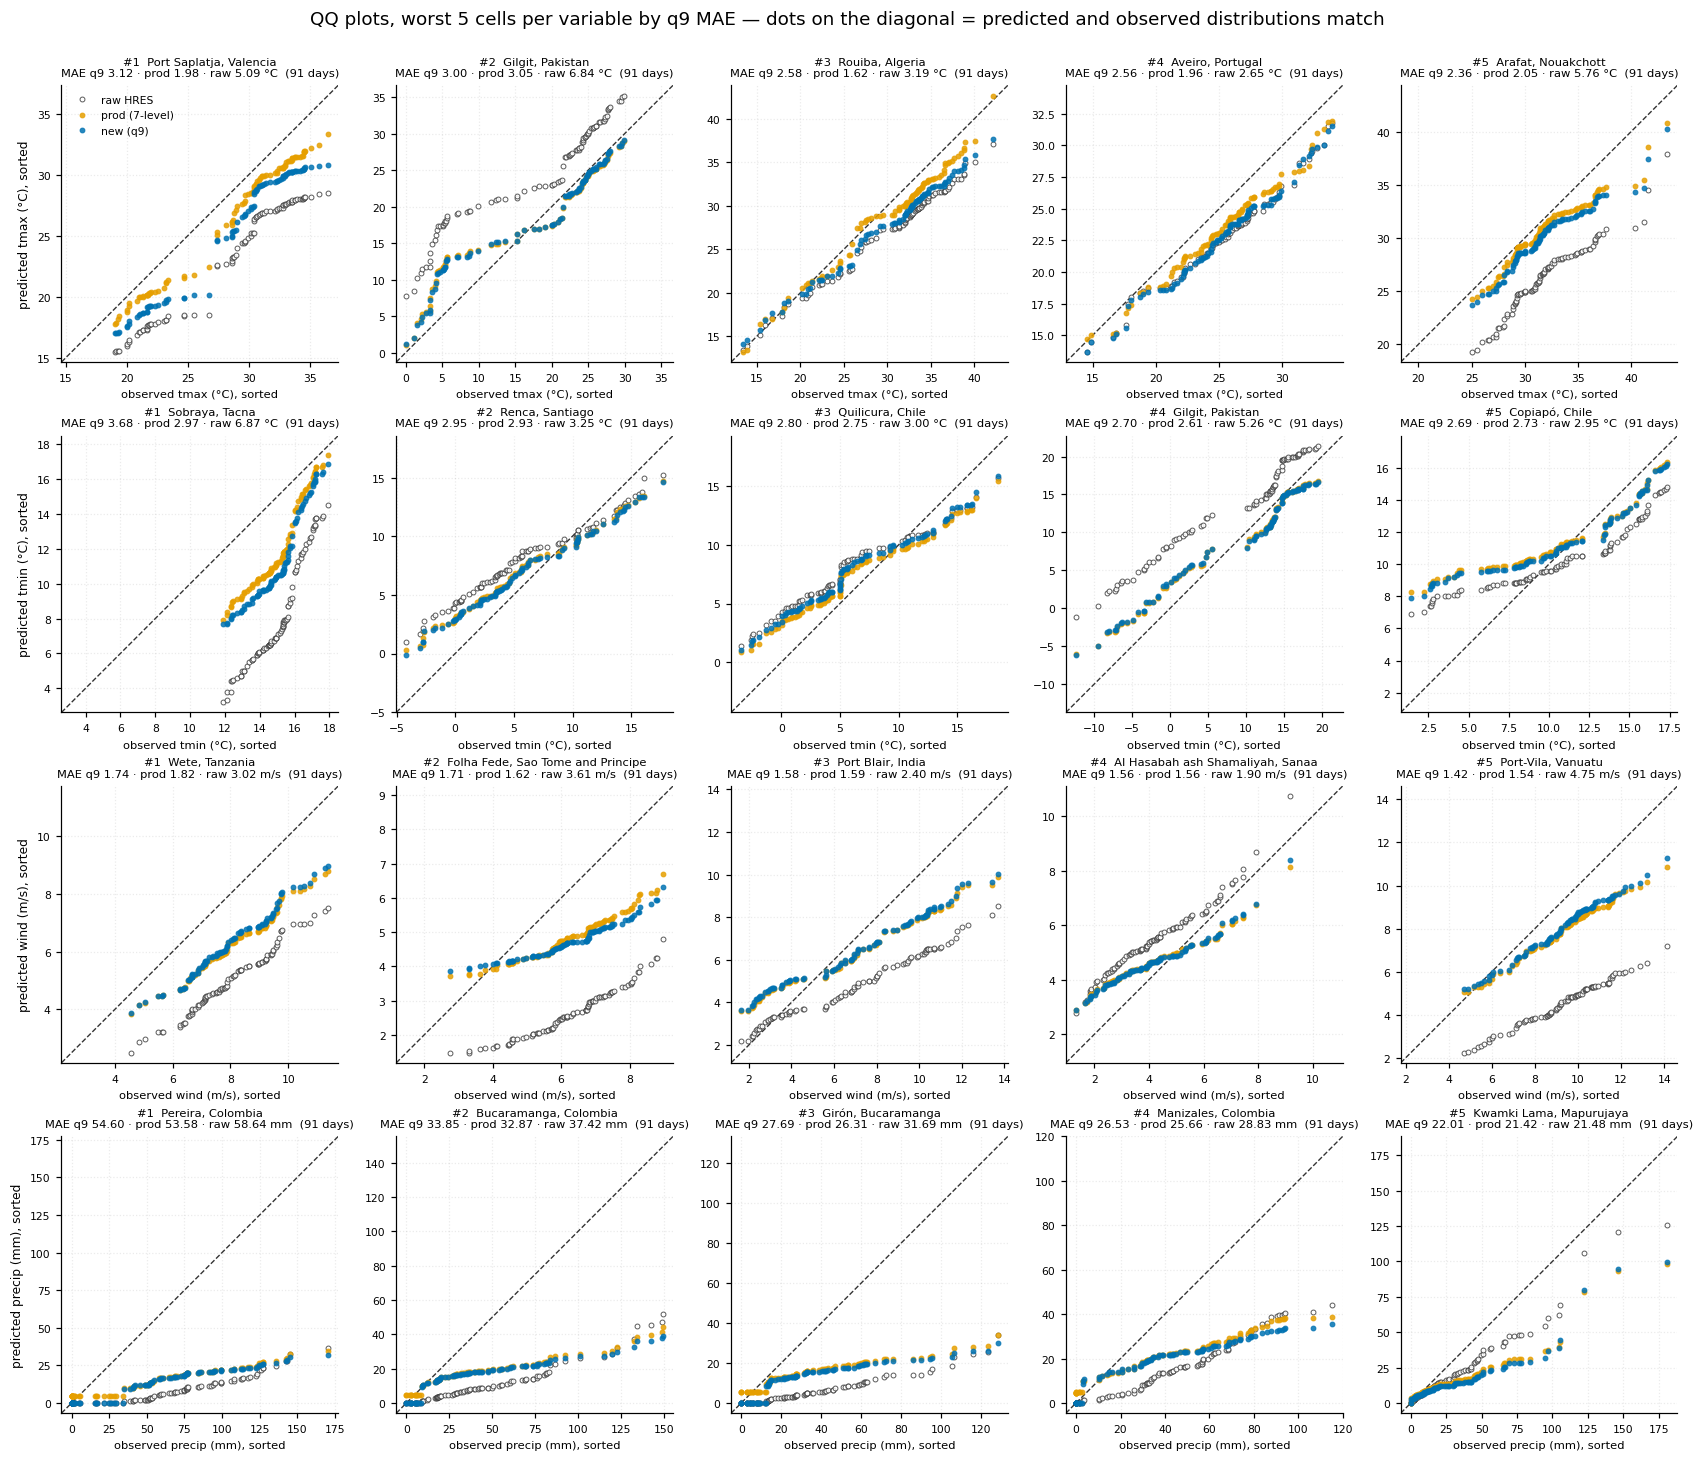

In [9]:
# --- figure 4: QQ plots for the cells where q9's point error is worst ------------
#     One panel per cell (columns = rank, rows = variable). The cell's eval days
#     sorted: x = observed value at each rank, y = predicted value at the same rank,
#     same three series as figure 1 (white = raw HRES, orange = prod, blue = q9).
#     Dashed diagonal = the prediction's distribution matches the truth's.
fig, axes = plt.subplots(len(VARS), N_WORST_CELLS,
                         figsize=(3.1 * N_WORST_CELLS, 3.3 * len(VARS)))
for row_i, var in enumerate(VARS):
    rows = full_rows[var]
    for col_i, key in enumerate(worst_by_error[var].index):
        ax = axes[row_i, col_i]
        cell = rows[rows.key == key]
        truth_sorted = np.sort(cell.truth_abs.to_numpy())
        lo_edge = truth_sorted.min(); hi_edge = truth_sorted.max()
        for label, col, color in SYSTEMS_POINT:
            is_raw = color == COLOR_RAW
            pred_sorted = np.sort(cell[col].to_numpy())
            lo_edge = min(lo_edge, pred_sorted.min()); hi_edge = max(hi_edge, pred_sorted.max())
            ax.plot(truth_sorted, pred_sorted, linestyle="", marker="o", markersize=3.2,
                    markerfacecolor="white" if is_raw else color,
                    markeredgecolor=INK if is_raw else color, markeredgewidth=0.6,
                    alpha=0.85, label=label, zorder=2 if is_raw else 3)
        pad = 0.04 * (hi_edge - lo_edge)
        ax.plot([lo_edge - pad, hi_edge + pad], [lo_edge - pad, hi_edge + pad],
                color=INK, lw=0.9, linestyle="--", zorder=1)
        ax.set_xlim(lo_edge - pad, hi_edge + pad); ax.set_ylim(lo_edge - pad, hi_edge + pad)
        ax.set_aspect("equal")
        mae = worst_by_error[var].loc[key]
        ax.set_title(f"#{col_i + 1}  {cell_label(key)}\n"
                     f"MAE q9 {mae['new (q9)']:.2f} · prod {mae['prod (7-level)']:.2f} · "
                     f"raw {mae['raw HRES']:.2f} {UNITS[var]}  ({int(mae.days)} days)",
                     fontsize=7.5)
        ax.set_xlabel(f"observed {var} ({UNITS[var]}), sorted", fontsize=7.5)
        ax.tick_params(labelsize=7)
    axes[row_i, 0].set_ylabel(f"predicted {var} ({UNITS[var]}), sorted", fontsize=8)
axes[0, 0].legend(fontsize=7, frameon=False, loc="upper left")
fig.suptitle(f"QQ plots, worst {N_WORST_CELLS} cells per variable by q9 MAE — "
             "dots on the diagonal = predicted and observed distributions match", y=1.0)
fig.tight_layout()
plt.show()

### Where the band fails, rung by rung

Figure 5 is the probabilistic twin of the QQ plot. For each worst-coverage cell and
each of the 9 quantile levels the card ships, x is the level's promise (q10 promises
that 10% of days land below it) and y is the fraction of the cell's days that actually
did. The diagonal is perfect calibration; the grey band is where a **perfect** band's
curve would still wander from binomial luck at that cell's day count (95% envelope) —
a curve inside it is indistinguishable from luck, a curve outside it is a real defect.

The **shape** names the defect: a whole curve *above* the diagonal means truth lands
below every level more often than promised — the band sits too high (a bias the model
missed); *below* the diagonal = the band sits too low; an S through the middle (above
at the low levels, below at the high ones) = the band is too narrow; the reverse S =
too wide. Three systems per panel, so it also says whether the failure belongs to the
*place* (all three off together) or to q9 alone.

Precip curves start above 0 at the lowest levels: on a wet-forecast day that turned out
dry, truth (0 mm) sits *at* every level clamped to 0 mm and counts as "at or below" — the
trace-clamp artifact from Part 2, not a defect of the band.

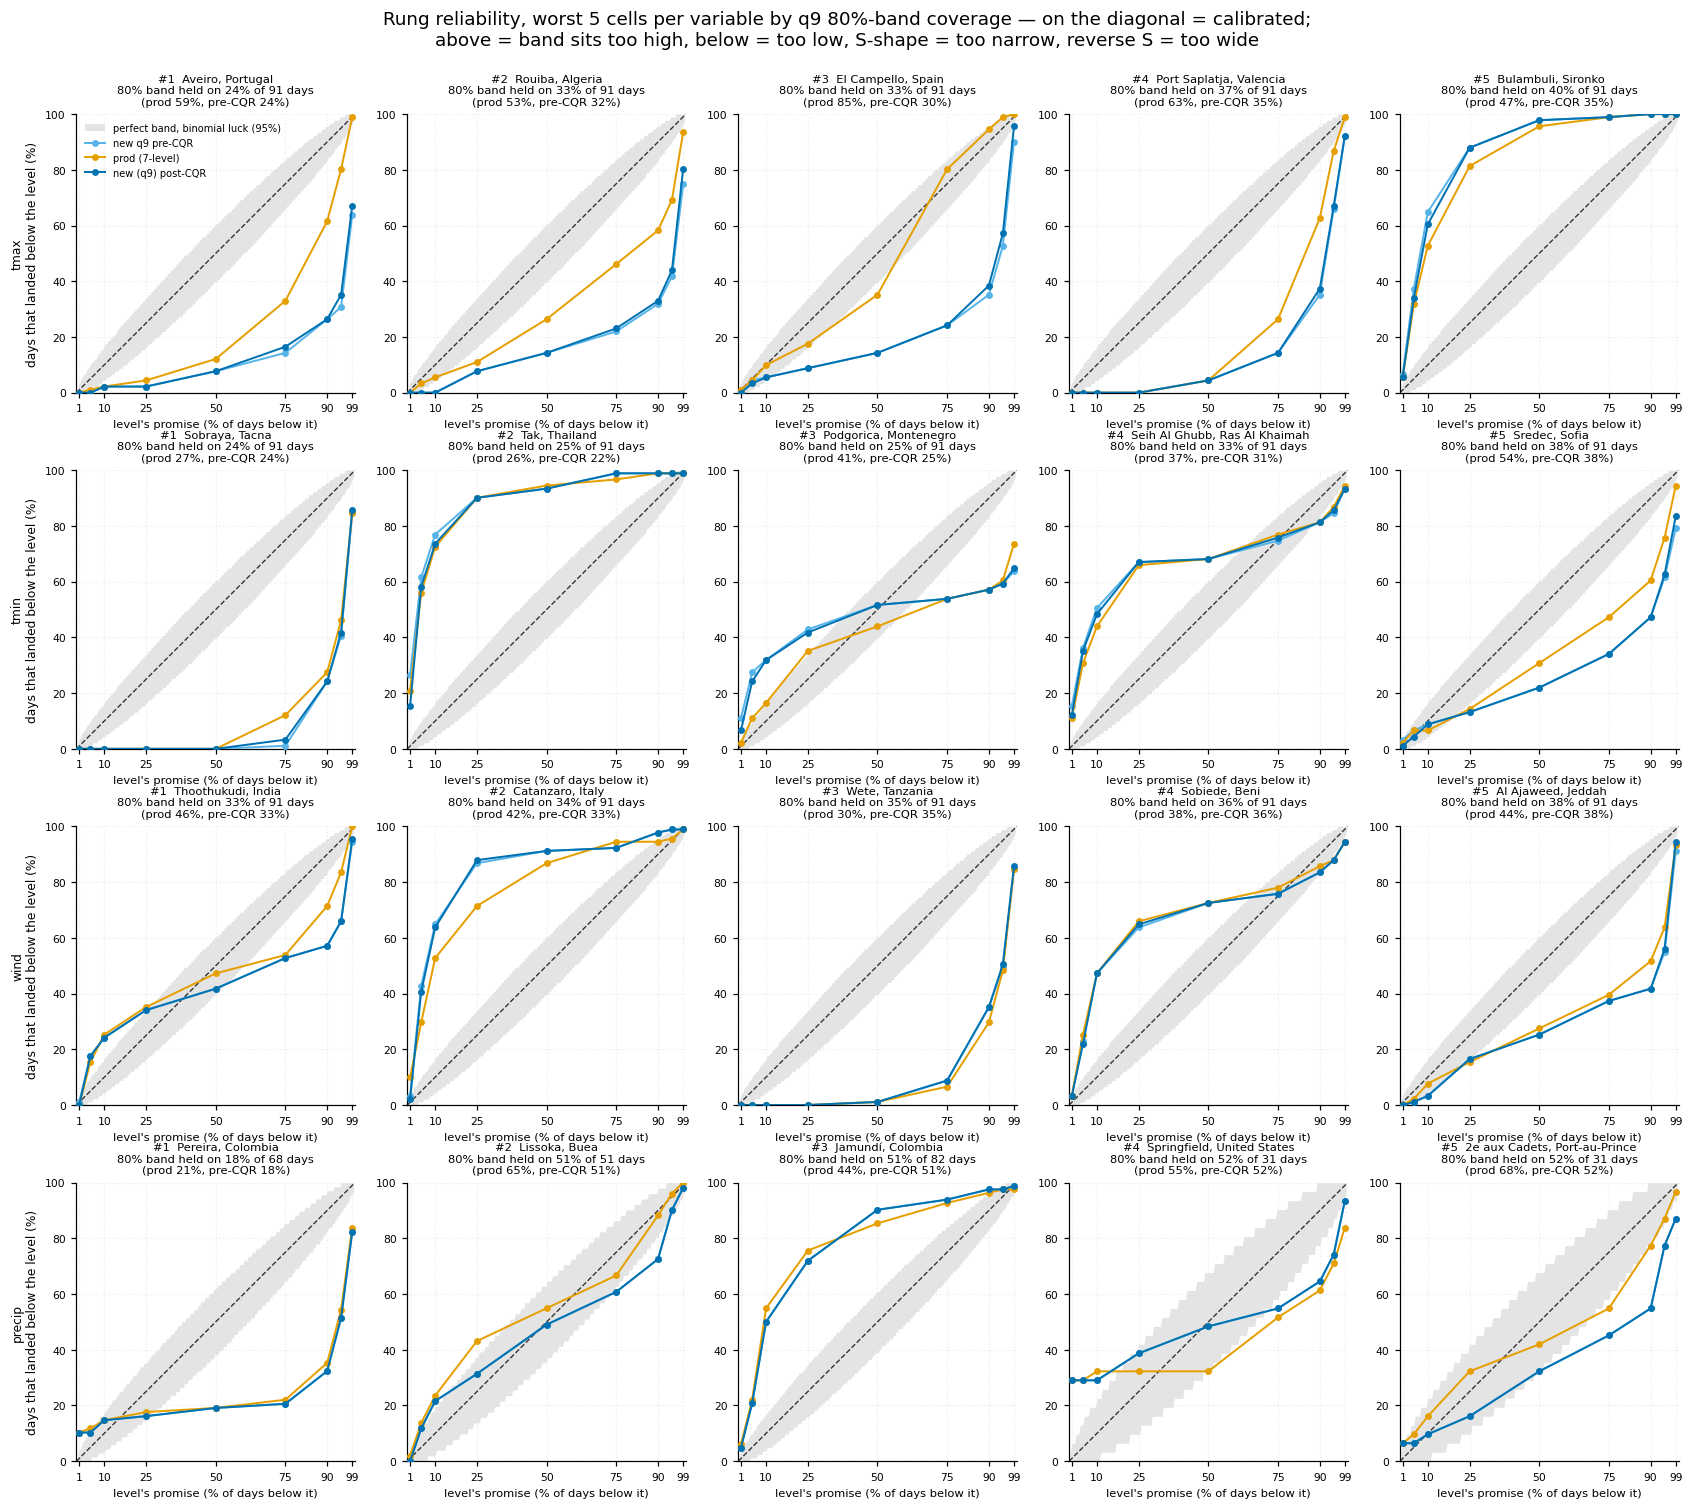

In [10]:
# --- figure 5: rung reliability for the cells whose q9 80% band held the fewest days
#     Per cell and system: x = each level's promise (BAND_P), y = the fraction of the
#     cell's days with truth <= that level. Grey = a PERFECT band's 95% binomial-luck
#     envelope at this cell's day count. Precip rows are wet-forecast only.
def rung_hit_rates(cell_rows, suffix):
    "fraction of the cell's days with truth at or below each of the 9 quantile levels."
    truth = cell_rows.truth_abs.to_numpy()
    return np.array([(truth <= cell_rows[col + suffix].to_numpy()).mean()
                     for col in BAND_COLS])

def luck_envelope(n_days, alpha=0.05):
    "95% binomial band a perfectly calibrated system's curve stays inside with n days."
    promise = np.linspace(0.005, 0.995, 200)
    return (promise, binom.ppf(alpha / 2, n_days, promise) / n_days,
            binom.ppf(1 - alpha / 2, n_days, promise) / n_days)

fig, axes = plt.subplots(len(VARS), N_WORST_CELLS,
                         figsize=(3.1 * N_WORST_CELLS, 3.4 * len(VARS)))
for row_i, var in enumerate(VARS):
    rows = coverage_rows[var]
    for col_i, key in enumerate(worst_by_coverage[var].index):
        ax = axes[row_i, col_i]
        cell = rows[rows.key == key]
        promise, luck_lo, luck_hi = luck_envelope(len(cell))
        ax.fill_between(100 * promise, 100 * luck_lo, 100 * luck_hi, color="#e4e4e4",
                        lw=0, zorder=1, label="perfect band, binomial luck (95%)")
        ax.plot([0, 100], [0, 100], color=INK, lw=0.9, linestyle="--", zorder=2)
        for label, suffix, color in SYSTEMS_BAND:
            ax.plot(100 * np.asarray(BAND_P), 100 * rung_hit_rates(cell, suffix),
                    marker="o", markersize=3.5, lw=1.3, color=color, label=label,
                    zorder=3)
        coverage = worst_by_coverage[var].loc[key]
        ax.set_title(f"#{col_i + 1}  {cell_label(key)}\n80% band held on "
                     f"{coverage['new (q9) post-CQR']:.0f}% of {int(coverage.days)} days\n"
                     f"(prod {coverage['prod (7-level)']:.0f}%, pre-CQR "
                     f"{coverage['new q9 pre-CQR']:.0f}%)", fontsize=7.5)
        ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.set_aspect("equal")
        ax.set_xticks([1, 10, 25, 50, 75, 90, 99])
        ax.set_xticklabels(["1", "10", "25", "50", "75", "90", "99"], fontsize=7)
        ax.tick_params(axis="y", labelsize=7)
        ax.set_xlabel("level's promise (% of days below it)", fontsize=7.5)
    axes[row_i, 0].set_ylabel(f"{var}\ndays that landed below the level (%)", fontsize=8)
axes[0, 0].legend(fontsize=6.5, frameon=False, loc="upper left")
fig.suptitle(f"Rung reliability, worst {N_WORST_CELLS} cells per variable by q9 80%-band "
             "coverage — on the diagonal = calibrated;\nabove = band sits too high, "
             "below = too low, S-shape = too narrow, reverse S = too wide", y=1.0)
fig.tight_layout()
plt.show()

## Reading it

**Point error (figures 1–2)**
- The signed-error boxes show what the models remove: raw HRES runs warm on tmax
  (+0.55 °C mean overall, +1.14 on claimed-extreme days) and over-forecasts wind
  (+0.63 m/s). Both models sit on the 0 line for ALL rows; inside the extreme tier both
  keep a small toward-climatology lean, q9 a touch more than prod (tmax +0.22 vs
  +0.08 °C).
- In MAE terms (headline table above): vs the raw feed q9 cuts ~34% (tmax), ~33%
  (tmin), ~49% (wind) and ~15% (precip) on ALL rows, most on extreme days (tmax
  1.56→0.85 °C, wind 1.57→0.74 m/s, precip 12.3→8.2 mm). q9 vs prod is a modest ~3–8%
  win everywhere **except `extreme` for tmax and precip, where the two are tied**
  (0.85 vs 0.85 °C; 8.16 vs 8.12 mm).

**Coverage (figure 3)**
- **The extreme tier** — the known weak spot — improves across the board vs prod
  (pooled table under the figure): wind −8.2 → −4.3 pp, tmax −3.7 → −2.7, tmin
  −0.7 → +0.6, precip −1.3 → +1.9. tmax/wind extremes still over-promise a little (the
  selection effect from the intro).
- **What CQR buys** is the sky→dark-blue gap: the raw q9 heads under-cover the temps
  (tmax 80% band ≈ −1.4 pp pooled, −4.9 in the extreme tier); the conformal shift pulls
  that to +0.7 / −2.7.
- **Across cells**: in the ALL column every system's box is wider than the grey
  perfect-band box, so band quality genuinely varies by place — the middle 50% of cells
  sit within roughly ±5 pp where binomial luck alone would give ±3, and the pooled
  number is the average of over- and under-covering cells, not the typical cell. q9's
  spread matches prod's: the retrain moved the promise, not the evenness. Inside the
  sparse tiers the grey boxes balloon (a handful of days per cell) — there, read the
  mean dots against the pooled table, not the whiskers.
- **Did tmin get worse? No.** q9's tmin band over-delivers slightly more than prod's
  (+1.5 vs +0.6 pp at the 80% band) — but it does so while being **4.7% narrower**
  (mean q90–q10 width 2.33 vs 2.44 °C, width table above). Covering more with a
  narrower band means the band is simply better placed; the same holds for tmax
  (−2.1% width) and wind (−5.8%).
- **Precip's sky and dark-blue boxes coincide** — the fitted per-level CQR shifts for
  precip are ≈0, so pre- and post-CQR bands are identical. Not a plotting bug. The wet
  mild tiers over-cover for everyone, prod included — partly the trace-clamp artifact:
  the band's low quantiles clamp to 0 mm, and every turned-out-dry outcome counts as
  covered there. q9 inherits it ~2.5 pp stronger.

**Worst cells (figures 4–5)**
- **q9's worst tmax cells are a regression, and they cluster on Mediterranean and
  Atlantic coasts.** Port Saplatja (Valencia), Rouiba, El Campello and Aveiro top both
  the MAE and the coverage lists, and there q9 is plainly *worse* than prod (Valencia
  MAE 3.12 vs 1.98 °C; Aveiro's 80% band held on 24% of days vs prod's 59%, El
  Campello 33% vs 85%). The QQ dots sit parallel below the diagonal and the
  reliability curves lie entirely under it: a constant 2–3 °C cold bias the model
  does not remove, not a width problem — and pre-CQR and post-CQR coincide, so the
  global conformal shift cannot reach it. At Valencia, El Campello and Rouiba the
  rebuilt feed reads ~2 °C colder than the feed prod consumed on the very same days
  (mean new − old −1.8 … −2.2 °C, correlation 0.98): the forecast gridpoint moved, the
  weather didn't. Aveiro's feed barely moved (+0.25 °C) and q9 still lost 0.6 °C of
  MAE and 35 pp of coverage to prod there. Across all cells it is contained — 24 tmax
  cells where q9 is worse than prod by >0.5 °C against 62 where it is better by as
  much (tmin 10 vs 103, wind 8 vs 197) — and a big feed shift is not by itself what
  hurts (cells with one are on average slightly *better* for q9: it learned most of
  them). The ones it didn't learn are coastal (Ashkelon, Mohammedia, Hadera, Ancona,
  Fremont join the list), and those are the kind of place people look up.
- **Elsewhere the worst cells belong to the place, not the model.** The same cells top
  both models' lists with near-identical numbers: Gilgit (raw tmax 6.8 °C off, both
  models ≈3.0), Sobraya/Tacna tmin (raw −6.9 °C, both ≈ −3, and every system's band
  holds on 24–27% of days), the small-island wind cells (Wete, São Tomé, Port-Vila:
  raw under-forecasts by 2–3 m/s, both models remove most of it) and the Colombian
  Andes precip cells (raw MAE 30–59 mm, either model shaves ~10%). Tak (Thailand) is
  the mirror case — everything sits *above* the diagonal, a tmin band too warm for
  both.
- **How many cells are genuinely mis-covered?** 11% of tmax cells, 9% of tmin and 11%
  of wind fall below their own 2.5% luck line (2.5% expected): roughly one cell in
  twelve carries an 80% band that under-covers for real, in every system. The worst
  hold on 24–35% of days, where a perfectly calibrated band's unluckiest cell would
  still read ≈64%. The failure shape is almost always a whole curve on one side of the
  diagonal (a missed per-cell bias), not an S (a wrong width) — the argument for the
  per-cell / per-tier remap over a global shift. Precip has only 1.2% beyond luck: its
  wet-day bands are, if anything, too wide.